In [ ]:
!pip install --upgrade --force-reinstall \
    "torch==2.5.1" \
    "transformers==4.46.3" \
    "datasets==3.1.0" \
    "pyarrow==18.1.0" \
    "accelerate>=0.26.0" \
    "sentencepiece" \
    "protobuf"

In [29]:
import os
import re
import json
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from transformers import pipeline
from tqdm.auto import tqdm
from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# Dataset and model
DATASET_NAME = "timonziegenbein/appropriateness-corpus"
MODEL_NAME = "timonziegenbein/appropriateness-classifier-binary"

# Columns
TEXT_COL = "post_text"
LABEL_COL = "Inappropriateness"
ID_COL = "post_id"

# Class labels used by the Hugging Face classifier
APPROPRIATE_LABEL = "LABEL_0"
INAPPROPRIATE_LABEL = "LABEL_1"

# Inference settings
MAX_LENGTH = 512
BATCH_SIZE = 16
DEVICE = 0 if torch.cuda.is_available() else -1

# TF-IDF settings
TFIDF_NGRAM_RANGE = (1, 1)
TFIDF_MIN_DF = 2
TFIDF_MAX_DF = 0.95
TFIDF_NORM = "l2"
TFIDF_SUBLINEAR_TF = True
TFIDF_STOP_WORDS = "english"

# Hyperparameter grid for validation selection
TOP_K_VALUES = [1, 3, 5, 10]
WINDOW_SIZE_VALUES = [0, 1, 2, 3]

# Output
BASE_DIR = Path("results")
OUTPUT_DIR = BASE_DIR / "tfidf_baseline_results"
BASE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)

Device: 0


In [31]:
pipe = pipeline(
    "text-classification",
    model=MODEL_NAME,
    device=DEVICE,
    top_k=None,
    truncation=True,
    max_length=MAX_LENGTH
)

MASK_TOKEN = pipe.tokenizer.mask_token if pipe.tokenizer.mask_token is not None else "[MASK]"

print("Mask token:", MASK_TOKEN)

Mask token: [MASK]


In [32]:
ds = load_dataset(DATASET_NAME)

train_df_raw = ds["train"].to_pandas()
val_df_raw = ds["validation"].to_pandas()
test_df_raw = ds["test"].to_pandas()

def attach_split(df, split_name):
    """Add a split column before creating global IDs."""
    df = df.copy().reset_index(drop=True)
    df["split"] = split_name
    return df

df_all = pd.concat(
    [
        attach_split(train_df_raw, "train"),
        attach_split(val_df_raw, "validation"),
        attach_split(test_df_raw, "test"),
    ],
    ignore_index=True
)

# Stable ID for comparing results across methods.
df_all["global_row_id"] = np.arange(len(df_all))

train_df = df_all[df_all["split"] == "train"].copy().reset_index(drop=True)
val_df = df_all[df_all["split"] == "validation"].copy().reset_index(drop=True)
test_df = df_all[df_all["split"] == "test"].copy().reset_index(drop=True)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

df_all[["global_row_id", "split", ID_COL, LABEL_COL, TEXT_COL]].head()

Train: (1533, 21)
Validation: (220, 21)
Test: (438, 21)


,global_row_id,split,post_id,Inappropriateness,post_text
0,0,train,1,1,"people cant be forced to wear school uniforms,..."
1,1,train,2,1,"That form of argument degrades this forum, and..."
2,2,train,3,0,I wouldnt turn her in becuase she is my wife. ...
3,3,train,4,1,No I wouldn't turn in my spouse. Just because ...
4,4,train,5,1,TV is terrible. Except for Spongebob maybe. Th...


In [33]:
def normalize_text(text: str) -> str:
    """
    Apply minimal normalization only.
    
    This keeps stylistic signals such as capitalization or punctuation mostly intact,
    while normalizing Unicode and whitespace.
    """
    if text is None:
        return ""
    
    text = unicodedata.normalize("NFKC", str(text))
    text = re.sub(r"\s+", " ", text).strip()
    return text


for df in [train_df, val_df, test_df]:
    df["text_norm"] = df[TEXT_COL].apply(normalize_text)

train_df[[TEXT_COL, "text_norm"]].head()

,post_text,text_norm
0,"people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,..."
1,"That form of argument degrades this forum, and...","That form of argument degrades this forum, and..."
2,I wouldnt turn her in becuase she is my wife. ...,I wouldnt turn her in becuase she is my wife. ...
3,No I wouldn't turn in my spouse. Just because ...,No I wouldn't turn in my spouse. Just because ...
4,TV is terrible. Except for Spongebob maybe. Th...,TV is terrible. Except for Spongebob maybe. Th...


In [34]:
def predict_with_pipeline(texts, batch_size=BATCH_SIZE):
    """
    Predict class probabilities and labels with the Hugging Face pipeline.
    
    Returns one row per input text with:
    - p_inappropriate_original
    - predicted_label
    - predicted_score
    """
    rows = []
    
    for start in tqdm(range(0, len(texts), batch_size), desc="Classifier inference"):
        batch_texts = texts[start:start + batch_size]
        outputs = pipe(batch_texts, batch_size=batch_size)
        
        for output in outputs:
            # With top_k=None, the pipeline returns a list of label-score dictionaries.
            if isinstance(output, dict):
                output = [output]
            
            score_by_label = {
                item["label"]: float(item["score"])
                for item in output
            }
            
            predicted_label = max(score_by_label, key=score_by_label.get)
            predicted_score = score_by_label[predicted_label]
            p_inappropriate = score_by_label.get(INAPPROPRIATE_LABEL, np.nan)
            
            rows.append({
                "p_inappropriate_original": p_inappropriate,
                "predicted_label": predicted_label,
                "predicted_score": predicted_score
            })
    
    return pd.DataFrame(rows)

In [35]:
def get_confusion_type(row):
    """Compute confusion type based on gold label and predicted label."""
    gold = int(row[LABEL_COL])
    pred_inappropriate = row["predicted_label"] == INAPPROPRIATE_LABEL

    if gold == 1 and pred_inappropriate:
        return "TP"
    if gold == 1 and not pred_inappropriate:
        return "FN"
    if gold == 0 and pred_inappropriate:
        return "FP"
    if gold == 0 and not pred_inappropriate:
        return "TN"
    
    return "UNKNOWN"


def add_classifier_outputs(df):
    """Add classifier probabilities, predicted labels, and confusion types."""
    df = df.copy()
    
    pred_df = predict_with_pipeline(
        df[TEXT_COL].astype(str).tolist(),
        batch_size=BATCH_SIZE
    )
    
    df = pd.concat(
        [df.reset_index(drop=True), pred_df.reset_index(drop=True)],
        axis=1
    )
    
    df["confusion_type"] = df.apply(get_confusion_type, axis=1)
    
    df["is_true_positive"] = df["confusion_type"] == "TP"
    df["is_false_negative"] = df["confusion_type"] == "FN"
    df["is_false_positive"] = df["confusion_type"] == "FP"
    df["is_true_negative"] = df["confusion_type"] == "TN"
    
    return df


train_df = add_classifier_outputs(train_df)
val_df = add_classifier_outputs(val_df)
test_df = add_classifier_outputs(test_df)

print("Train confusion types:")
display(train_df["confusion_type"].value_counts())

print("Validation confusion types:")
display(val_df["confusion_type"].value_counts())

print("Test confusion types:")
display(test_df["confusion_type"].value_counts())

Classifier inference:   0%|          | 0/96 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/14 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/28 [00:00<?, ?it/s]

Train confusion types:


confusion_type
TP    785
TN    652
FN     48
FP     48
Name: count, dtype: int64

Validation confusion types:


confusion_type
TP    88
TN    66
FN    36
FP    30
Name: count, dtype: int64

Test confusion types:


confusion_type
TP    186
TN    142
FP     71
FN     39
Name: count, dtype: int64

# Fit TF-IDF Vectorizer on test set and find config on validation set

In [36]:
tfidf_vectorizer_val = TfidfVectorizer(
    lowercase=True,
    stop_words=TFIDF_STOP_WORDS,
    ngram_range=TFIDF_NGRAM_RANGE,
    min_df=TFIDF_MIN_DF,
    max_df=TFIDF_MAX_DF,
    norm=TFIDF_NORM,
    sublinear_tf=TFIDF_SUBLINEAR_TF
)

# For validation config selection, fit only on train.
X_train_tfidf = tfidf_vectorizer_val.fit_transform(train_df["text_norm"])
X_val_tfidf = tfidf_vectorizer_val.transform(val_df["text_norm"])

feature_names_val = np.array(tfidf_vectorizer_val.get_feature_names_out())

print("Train TF-IDF:", X_train_tfidf.shape)
print("Validation TF-IDF:", X_val_tfidf.shape)
print("Vocabulary size:", len(feature_names_val))

Train TF-IDF: (1533, 4668)
Validation TF-IDF: (220, 4668)
Vocabulary size: 4668


In [37]:
def get_top_tfidf_terms(X, matrix_pos, feature_names, top_k=5):
    """Return the top-k TF-IDF terms for one document row."""
    row = X[matrix_pos]
    
    if row.nnz == 0:
        return []
    
    indices = row.indices
    scores = row.data
    top_positions = np.argsort(scores)[::-1][:top_k]
    
    return [
        {
            "term": feature_names[indices[pos]],
            "tfidf": float(scores[pos])
        }
        for pos in top_positions
    ]


def tokenize_with_offsets(text):
    """Tokenize text into word tokens with character offsets."""
    tokens = []
    
    for token_idx, match in enumerate(re.finditer(r"\b\w+\b", text)):
        tokens.append({
            "token_idx": token_idx,
            "token": match.group(0),
            "token_lower": match.group(0).lower(),
            "start": match.start(),
            "end": match.end()
        })
    
    return tokens


def compute_tfidf_coverage_for_argument(text, X, matrix_pos, feature_names):
    """
    Compute TF-IDF coverage for one argument.
    
    word_tfidf_nonzero_ratio:
        Share of word tokens that correspond to active TF-IDF features.
    
    vector_nonzero_ratio:
        Share of active TF-IDF features relative to the full vocabulary.
    """
    tokens = tokenize_with_offsets(text)
    row = X[matrix_pos]
    
    active_feature_terms = set(feature_names[row.indices])
    
    if len(tokens) == 0:
        word_nonzero_count = 0
        word_tfidf_nonzero_ratio = 0.0
    else:
        word_nonzero_count = sum(
            1 for tok in tokens
            if tok["token_lower"] in active_feature_terms
        )
        word_tfidf_nonzero_ratio = word_nonzero_count / len(tokens)
    
    vector_nonzero_count = int(row.nnz)
    vector_nonzero_ratio = row.nnz / len(feature_names) if len(feature_names) > 0 else 0.0
    
    return {
        "n_word_tokens": len(tokens),
        "n_word_tokens_with_nonzero_tfidf": int(word_nonzero_count),
        "word_tfidf_nonzero_ratio": float(word_tfidf_nonzero_ratio),
        "n_nonzero_tfidf_features": int(vector_nonzero_count),
        "tfidf_vocab_size": int(len(feature_names)),
        "vector_nonzero_ratio": float(vector_nonzero_ratio)
    }


def find_anchor_tokens(text, top_terms):
    """Find all occurrences of top TF-IDF terms in the original text."""
    tokens = tokenize_with_offsets(text)
    top_term_lookup = {
        item["term"].lower(): item
        for item in top_terms
    }
    
    anchors = []
    
    for tok in tokens:
        if tok["token_lower"] in top_term_lookup:
            term_info = top_term_lookup[tok["token_lower"]]
            
            anchors.append({
                "anchor_token_idx": tok["token_idx"],
                "anchor_token": tok["token"],
                "anchor_start_char": tok["start"],
                "anchor_end_char": tok["end"],
                "anchor_term": term_info["term"],
                "anchor_tfidf": term_info["tfidf"]
            })
    
    return tokens, anchors


def build_window_spans(text, top_terms, window_size):
    """Expand each TF-IDF anchor term by a fixed token window."""
    tokens, anchors = find_anchor_tokens(text, top_terms)
    
    spans = []
    
    for anchor in anchors:
        anchor_idx = anchor["anchor_token_idx"]
        
        token_start_idx = max(0, anchor_idx - window_size)
        token_end_idx = min(len(tokens) - 1, anchor_idx + window_size)
        
        char_start = tokens[token_start_idx]["start"]
        char_end = tokens[token_end_idx]["end"]
        
        spans.append({
            "char_start": char_start,
            "char_end": char_end,
            "token_start_idx": token_start_idx,
            "token_end_idx": token_end_idx,
            "span_text": text[char_start:char_end],
            "anchor_token_idx": anchor_idx,
            "anchor_token": anchor["anchor_token"],
            "anchor_term": anchor["anchor_term"],
            "anchor_tfidf": anchor["anchor_tfidf"],
            "window_size": int(window_size)
        })
    
    return spans


def merge_window_spans(spans, original_text):
    """Merge overlapping or directly adjacent window spans."""
    if not spans:
        return []
    
    spans = sorted(spans, key=lambda x: (x["char_start"], x["char_end"]))
    merged = []
    
    for span in spans:
        span = span.copy()
        span["anchors"] = [{
            "anchor_token_idx": span.pop("anchor_token_idx"),
            "anchor_token": span.pop("anchor_token"),
            "anchor_term": span.pop("anchor_term"),
            "anchor_tfidf": span.pop("anchor_tfidf")
        }]
        
        if not merged:
            merged.append(span)
            continue
        
        previous = merged[-1]
        overlaps = span["char_start"] <= previous["char_end"]
        between = original_text[previous["char_end"]:span["char_start"]]
        adjacent = between.strip() == ""
        
        if overlaps or adjacent:
            previous["char_end"] = max(previous["char_end"], span["char_end"])
            previous["token_start_idx"] = min(previous["token_start_idx"], span["token_start_idx"])
            previous["token_end_idx"] = max(previous["token_end_idx"], span["token_end_idx"])
            previous["span_text"] = original_text[previous["char_start"]:previous["char_end"]]
            previous["anchors"].extend(span["anchors"])
        else:
            merged.append(span)
    
    for span_idx, span in enumerate(merged):
        span["span_idx"] = int(span_idx)
        span["span_len_chars"] = int(span["char_end"] - span["char_start"])
        span["span_len_tokens"] = int(span["token_end_idx"] - span["token_start_idx"] + 1)
        span["span_score_sum_tfidf"] = float(
            sum(anchor["anchor_tfidf"] for anchor in span["anchors"])
        )
    
    return merged


def mask_spans_in_text(text, spans, mask_token):
    """Replace extracted spans with the model mask token."""
    if not spans:
        return text
    
    spans = sorted(spans, key=lambda x: x["char_start"])
    
    masked_parts = []
    last_end = 0
    
    for span in spans:
        start = span["char_start"]
        end = span["char_end"]
        
        if start < last_end:
            continue
        
        masked_parts.append(text[last_end:start])
        masked_parts.append(mask_token)
        last_end = end
    
    masked_parts.append(text[last_end:])
    
    return "".join(masked_parts)

In [38]:
def run_tfidf_config_on_indices(
    df,
    X_tfidf,
    feature_names,
    matrix_positions,
    top_k_values,
    window_size_values,
    mask_token=MASK_TOKEN
):
    """
    Run TF-IDF span extraction and perturbation scoring.
    
    matrix_positions are split-local positions into df and X_tfidf.
    global_row_id is stored as the stable identifier for downstream comparison.
    """
    assert len(df) == X_tfidf.shape[0], "df and X_tfidf must have the same row order."
    
    all_results = []
    masked_texts_to_score = []
    masked_lookup = []
    
    for matrix_pos in tqdm(matrix_positions, desc="Building TF-IDF spans"):
        row = df.iloc[matrix_pos]
        
        text = str(row[TEXT_COL])
        label = int(row[LABEL_COL])
        
        coverage = compute_tfidf_coverage_for_argument(
            text=text,
            X=X_tfidf,
            matrix_pos=matrix_pos,
            feature_names=feature_names
        )
        
        top_terms_max = get_top_tfidf_terms(
            X=X_tfidf,
            matrix_pos=matrix_pos,
            feature_names=feature_names,
            top_k=max(top_k_values)
        )
        
        for window_size in window_size_values:
            for top_k in top_k_values:
                top_terms = top_terms_max[:top_k]
                
                window_spans = build_window_spans(
                    text=text,
                    top_terms=top_terms,
                    window_size=window_size
                )
                
                merged_spans = merge_window_spans(
                    spans=window_spans,
                    original_text=text
                )
                
                masked_text = mask_spans_in_text(
                    text=text,
                    spans=merged_spans,
                    mask_token=mask_token
                )
                
                total_masked_tokens = sum(span["span_len_tokens"] for span in merged_spans)
                total_masked_chars = sum(span["span_len_chars"] for span in merged_spans)
                masked_token_ratio = (
                    total_masked_tokens / coverage["n_word_tokens"]
                    if coverage["n_word_tokens"] > 0
                    else 0.0
                )
                
                result = {
                    "global_row_id": int(row["global_row_id"]),
                    "split": row["split"],
                    "post_id": row[ID_COL] if ID_COL in df.columns else None,
                    "issue": row["issue"] if "issue" in df.columns else None,
                    
                    "label": label,
                    "predicted_label": row["predicted_label"],
                    "predicted_score": float(row["predicted_score"]),
                    "confusion_type": row["confusion_type"],
                    "is_true_positive": bool(row["is_true_positive"]),
                    "is_false_negative": bool(row["is_false_negative"]),
                    "is_false_positive": bool(row["is_false_positive"]),
                    "is_true_negative": bool(row["is_true_negative"]),
                    
                    "top_k": int(top_k),
                    "window_size": int(window_size),
                    
                    "text": text,
                    "masked_text": masked_text,
                    
                    "p_inappropriate_original": float(row["p_inappropriate_original"]),
                    
                    **coverage,
                    
                    "n_merged_spans": int(len(merged_spans)),
                    "total_masked_tokens": int(total_masked_tokens),
                    "total_masked_chars": int(total_masked_chars),
                    "masked_token_ratio": float(masked_token_ratio),
                    
                    "top_terms": top_terms,
                    "window_spans": window_spans,
                    "merged_spans": merged_spans
                }
                
                all_results.append(result)
                masked_lookup.append(len(all_results) - 1)
                masked_texts_to_score.append(masked_text)
    
    masked_predictions = predict_with_pipeline(
        masked_texts_to_score,
        batch_size=BATCH_SIZE
    )
    
    for result_idx, (_, pred_row) in zip(masked_lookup, masked_predictions.iterrows()):
        result = all_results[result_idx]
        p_masked = float(pred_row["p_inappropriate_original"])
        
        result["p_inappropriate_masked"] = p_masked
        result["predicted_label_masked"] = pred_row["predicted_label"]
        result["prob_drop"] = float(result["p_inappropriate_original"] - p_masked)
    
    return all_results

In [39]:
def build_argument_level_df(argument_results):
    """Flatten argument-level results for CSV export."""
    rows = []
    
    for result in argument_results:
        merged_span_texts = [span["span_text"] for span in result["merged_spans"]]
        merged_span_token_starts = [span["token_start_idx"] for span in result["merged_spans"]]
        merged_span_token_ends = [span["token_end_idx"] for span in result["merged_spans"]]
        merged_span_char_starts = [span["char_start"] for span in result["merged_spans"]]
        merged_span_char_ends = [span["char_end"] for span in result["merged_spans"]]
        
        rows.append({
            "global_row_id": result["global_row_id"],
            "split": result["split"],
            "post_id": result["post_id"],
            "issue": result["issue"],
            
            "label": result["label"],
            "predicted_label": result["predicted_label"],
            "predicted_score": result["predicted_score"],
            "confusion_type": result["confusion_type"],
            "is_true_positive": result["is_true_positive"],
            "is_false_negative": result["is_false_negative"],
            "is_false_positive": result["is_false_positive"],
            "is_true_negative": result["is_true_negative"],
            
            "top_k": result["top_k"],
            "window_size": result["window_size"],
            
            "p_inappropriate_original": result["p_inappropriate_original"],
            "p_inappropriate_masked": result["p_inappropriate_masked"],
            "predicted_label_masked": result["predicted_label_masked"],
            "prob_drop": result["prob_drop"],
            
            "n_word_tokens": result["n_word_tokens"],
            "n_word_tokens_with_nonzero_tfidf": result["n_word_tokens_with_nonzero_tfidf"],
            "word_tfidf_nonzero_ratio": result["word_tfidf_nonzero_ratio"],
            "n_nonzero_tfidf_features": result["n_nonzero_tfidf_features"],
            "tfidf_vocab_size": result["tfidf_vocab_size"],
            "vector_nonzero_ratio": result["vector_nonzero_ratio"],
            
            "n_merged_spans": result["n_merged_spans"],
            "total_masked_tokens": result["total_masked_tokens"],
            "total_masked_chars": result["total_masked_chars"],
            "masked_token_ratio": result["masked_token_ratio"],
            
            "merged_span_texts": merged_span_texts,
            "merged_span_token_start_indices": merged_span_token_starts,
            "merged_span_token_end_indices": merged_span_token_ends,
            "merged_span_char_start_indices": merged_span_char_starts,
            "merged_span_char_end_indices": merged_span_char_ends,
            
            "top_terms_json": json.dumps(result["top_terms"], ensure_ascii=False),
            "merged_spans_json": json.dumps(result["merged_spans"], ensure_ascii=False),
            
            "text": result["text"],
            "masked_text": result["masked_text"]
        })
    
    return pd.DataFrame(rows)


def build_span_level_df(argument_results):
    """Flatten span-level results for CSV export."""
    span_rows = []
    
    for result in argument_results:
        for span in result["merged_spans"]:
            anchor_terms = [a["anchor_term"] for a in span["anchors"]]
            anchor_token_indices = [a["anchor_token_idx"] for a in span["anchors"]]
            anchor_tfidf_values = [a["anchor_tfidf"] for a in span["anchors"]]
            
            span_rows.append({
                "global_row_id": result["global_row_id"],
                "split": result["split"],
                "post_id": result["post_id"],
                "issue": result["issue"],
                
                "label": result["label"],
                "predicted_label": result["predicted_label"],
                "confusion_type": result["confusion_type"],
                "is_true_positive": result["is_true_positive"],
                "is_false_negative": result["is_false_negative"],
                "is_false_positive": result["is_false_positive"],
                "is_true_negative": result["is_true_negative"],
                
                "top_k": result["top_k"],
                "window_size": result["window_size"],
                
                "span_idx": span["span_idx"],
                "span_text": span["span_text"],
                "char_start": span["char_start"],
                "char_end": span["char_end"],
                "token_start_idx": span["token_start_idx"],
                "token_end_idx": span["token_end_idx"],
                "span_len_chars": span["span_len_chars"],
                "span_len_tokens": span["span_len_tokens"],
                
                "anchor_terms": anchor_terms,
                "anchor_token_indices": anchor_token_indices,
                "anchor_tfidf_values": anchor_tfidf_values,
                "span_score_sum_tfidf": span["span_score_sum_tfidf"],
                
                "p_inappropriate_original": result["p_inappropriate_original"],
                "p_inappropriate_masked": result["p_inappropriate_masked"],
                "prob_drop": result["prob_drop"],
                
                "n_word_tokens": result["n_word_tokens"],
                "word_tfidf_nonzero_ratio": result["word_tfidf_nonzero_ratio"],
                "vector_nonzero_ratio": result["vector_nonzero_ratio"],
                
                "text": result["text"],
                "masked_text": result["masked_text"]
            })
    
    return pd.DataFrame(span_rows)

In [40]:
val_tp_positions = val_df.index[val_df["confusion_type"] == "TP"].tolist()

print("Validation examples:", len(val_df))
print("Validation true positives:", len(val_tp_positions))

val_tp_results = run_tfidf_config_on_indices(
    df=val_df,
    X_tfidf=X_val_tfidf,
    feature_names=feature_names_val,
    matrix_positions=val_tp_positions,
    top_k_values=TOP_K_VALUES,
    window_size_values=WINDOW_SIZE_VALUES,
    mask_token=MASK_TOKEN
)

val_tp_argument_df = build_argument_level_df(val_tp_results)
val_tp_span_df = build_span_level_df(val_tp_results)

display(val_tp_argument_df.head())
display(val_tp_span_df.head())

Validation examples: 220
Validation true positives: 88


Building TF-IDF spans:   0%|          | 0/88 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/88 [00:00<?, ?it/s]

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,masked_token_ratio,merged_span_texts,merged_span_token_start_indices,merged_span_token_end_indices,merged_span_char_start_indices,merged_span_char_end_indices,top_terms_json,merged_spans_json,text,masked_text
0,1533,validation,28,Pro choice vs pro life:,1,LABEL_1,0.998432,TP,True,False,...,0.019231,[pregnancy],[51],[51],[252],[261],"[{""term"": ""pregnancy"", ""tfidf"": 0.364534980160...","[{""char_start"": 252, ""char_end"": 261, ""token_s...","The only other choices are, adoption or keep i...","The only other choices are, adoption or keep i..."
1,1533,validation,28,Pro choice vs pro life:,1,LABEL_1,0.998432,TP,True,False,...,0.057692,"[choices, suffer, pregnancy]","[3, 34, 51]","[3, 34, 51]","[15, 168, 252]","[22, 174, 261]","[{""term"": ""pregnancy"", ""tfidf"": 0.364534980160...","[{""char_start"": 15, ""char_end"": 22, ""token_sta...","The only other choices are, adoption or keep i...","The only other [MASK] are, adoption or keep it..."
2,1533,validation,28,Pro choice vs pro life:,1,LABEL_1,0.998432,TP,True,False,...,0.096154,"[choices, adoption, suffer, decide, pregnancy]","[3, 5, 34, 48, 51]","[3, 5, 34, 48, 51]","[15, 28, 168, 234, 252]","[22, 36, 174, 240, 261]","[{""term"": ""pregnancy"", ""tfidf"": 0.364534980160...","[{""char_start"": 15, ""char_end"": 22, ""token_sta...","The only other choices are, adoption or keep i...","The only other [MASK] are, [MASK] or keep it.\..."
3,1533,validation,28,Pro choice vs pro life:,1,LABEL_1,0.998432,TP,True,False,...,0.192308,"[choices, adoption, children, abortion, let, s...","[3, 5, 13, 30, 32, 34, 38, 42, 48, 51]","[3, 5, 13, 30, 32, 34, 38, 42, 48, 51]","[15, 28, 66, 146, 159, 168, 188, 208, 234, 252]","[22, 36, 74, 154, 162, 174, 194, 213, 240, 261]","[{""term"": ""pregnancy"", ""tfidf"": 0.364534980160...","[{""char_start"": 15, ""char_end"": 22, ""token_sta...","The only other choices are, adoption or keep i...","The only other [MASK] are, [MASK] or keep it.\..."
4,1533,validation,28,Pro choice vs pro life:,1,LABEL_1,0.998432,TP,True,False,...,0.038462,[womans pregnancy],[50],[51],[245],[261],"[{""term"": ""pregnancy"", ""tfidf"": 0.364534980160...","[{""char_start"": 245, ""char_end"": 261, ""token_s...","The only other choices are, adoption or keep i...","The only other choices are, adoption or keep i..."


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,anchor_tfidf_values,span_score_sum_tfidf,p_inappropriate_original,p_inappropriate_masked,prob_drop,n_word_tokens,word_tfidf_nonzero_ratio,vector_nonzero_ratio,text,masked_text
0,1533,validation,28,Pro choice vs pro life:,1,LABEL_1,TP,True,False,False,...,[0.36453498016098956],0.364535,0.998432,0.998402,0.00003,52,0.269231,0.002999,"The only other choices are, adoption or keep i...","The only other choices are, adoption or keep i..."
1,1533,validation,28,Pro choice vs pro life:,1,LABEL_1,TP,True,False,False,...,[0.33906251966585577],0.339063,0.998432,0.998452,-0.00002,52,0.269231,0.002999,"The only other choices are, adoption or keep i...","The only other [MASK] are, adoption or keep it..."
2,1533,validation,28,Pro choice vs pro life:,1,LABEL_1,TP,True,False,False,...,[0.35465382528501915],0.354654,0.998432,0.998452,-0.00002,52,0.269231,0.002999,"The only other choices are, adoption or keep i...","The only other [MASK] are, adoption or keep it..."
3,1533,validation,28,Pro choice vs pro life:,1,LABEL_1,TP,True,False,False,...,[0.36453498016098956],0.364535,0.998432,0.998452,-0.00002,52,0.269231,0.002999,"The only other choices are, adoption or keep i...","The only other [MASK] are, adoption or keep it..."
4,1533,validation,28,Pro choice vs pro life:,1,LABEL_1,TP,True,False,False,...,[0.33906251966585577],0.339063,0.998432,0.998362,0.00007,52,0.269231,0.002999,"The only other choices are, adoption or keep i...","The only other [MASK] are, [MASK] or keep it.\..."


In [41]:
val_config_summary = (
    val_tp_argument_df
    .groupby(["window_size", "top_k"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        median_total_masked_tokens=("total_masked_tokens", "median"),
        mean_total_masked_chars=("total_masked_chars", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        median_masked_token_ratio=("masked_token_ratio", "median"),
        mean_word_tfidf_nonzero_ratio=("word_tfidf_nonzero_ratio", "mean"),
        mean_vector_nonzero_ratio=("vector_nonzero_ratio", "mean"),
    )
    .reset_index()
)

span_len_summary = (
    val_tp_span_df
    .groupby(["window_size", "top_k"])
    .agg(
        n_spans=("span_text", "count"),
        mean_span_len_tokens=("span_len_tokens", "mean"),
        median_span_len_tokens=("span_len_tokens", "median"),
        mean_span_len_chars=("span_len_chars", "mean"),
        median_span_len_chars=("span_len_chars", "median"),
    )
    .reset_index()
)

val_config_summary = val_config_summary.merge(
    span_len_summary,
    on=["window_size", "top_k"],
    how="left"
)

val_config_summary["prob_drop_per_masked_token"] = (
    val_config_summary["mean_prob_drop"] /
    val_config_summary["mean_total_masked_tokens"].replace(0, np.nan)
)

val_config_summary["prob_drop_per_masked_ratio"] = (
    val_config_summary["mean_prob_drop"] /
    val_config_summary["mean_masked_token_ratio"].replace(0, np.nan)
)

val_config_summary = val_config_summary.sort_values(["window_size", "top_k"])

display(val_config_summary)

,window_size,top_k,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,...,median_masked_token_ratio,mean_word_tfidf_nonzero_ratio,mean_vector_nonzero_ratio,n_spans,mean_span_len_tokens,median_span_len_tokens,mean_span_len_chars,median_span_len_chars,prob_drop_per_masked_token,prob_drop_per_masked_ratio
0,0,1,88,-0.008098,-0.000062,0.044324,0.981915,0.990013,2.181818,2.181818,...,0.029857,0.362107,0.005139,192,1.000000,1.0,6.390625,6.0,-0.003711,-0.207233
1,0,3,88,-0.014030,-0.000041,0.060241,0.981915,0.995945,5.113636,5.545455,...,0.073223,0.362107,0.005139,450,1.084444,1.0,6.871111,6.0,-0.002530,-0.140912
2,0,5,88,-0.014165,0.000042,0.059601,0.981915,0.996080,7.375000,8.090909,...,0.111905,0.362107,0.005139,649,1.097072,1.0,6.841294,6.0,-0.001751,-0.098582
3,0,10,88,-0.006748,0.000210,0.070861,0.981915,0.988664,10.886364,12.681818,...,0.175631,0.362107,0.005139,958,1.164927,1.0,7.290188,6.0,-0.000532,-0.031436
4,1,1,88,-0.008379,-0.000049,0.071789,0.981915,0.990294,2.102273,6.431818,...,0.089572,0.362107,0.005139,185,3.059459,3.0,17.589189,17.0,-0.001303,-0.074312
5,1,3,88,-0.010250,0.000008,0.064789,0.981915,0.992166,4.375000,15.090909,...,0.206715,0.362107,0.005139,385,3.449351,3.0,19.410390,17.0,-0.000679,-0.038798
6,1,5,88,-0.009160,0.000030,0.080275,0.981915,0.991075,5.727273,21.590909,...,0.288378,0.362107,0.005139,504,3.769841,3.0,20.837302,17.5,-0.000424,-0.024737
7,1,10,88,-0.003194,0.000203,0.103138,0.981915,0.985110,7.215909,31.715909,...,0.454864,0.362107,0.005139,635,4.395276,3.0,24.348031,19.0,-0.000101,-0.006298
8,2,1,88,-0.001291,-0.000110,0.108678,0.981915,0.983207,2.034091,10.477273,...,0.146629,0.362107,0.005139,179,5.150838,5.0,28.793296,28.0,-0.000123,-0.007066
9,2,3,88,-0.001704,0.000016,0.098093,0.981915,0.983620,3.863636,23.136364,...,0.318878,0.362107,0.005139,340,5.988235,5.0,33.114706,29.0,-0.000074,-0.004347


In [42]:
val_output_dir = OUTPUT_DIR / "validation_config_selection"
val_output_dir.mkdir(parents=True, exist_ok=True)

val_tp_argument_df.to_csv(
    val_output_dir / "tfidf_validation_tp_argument_level.csv",
    index=False,
    encoding="utf-8"
)

val_tp_span_df.to_csv(
    val_output_dir / "tfidf_validation_tp_span_level.csv",
    index=False,
    encoding="utf-8"
)

val_config_summary.to_csv(
    val_output_dir / "tfidf_validation_config_summary.csv",
    index=False,
    encoding="utf-8"
)

print("Saved validation config selection files to:", val_output_dir)

Saved validation config selection files to: tfidf_baseline_results/validation_config_selection


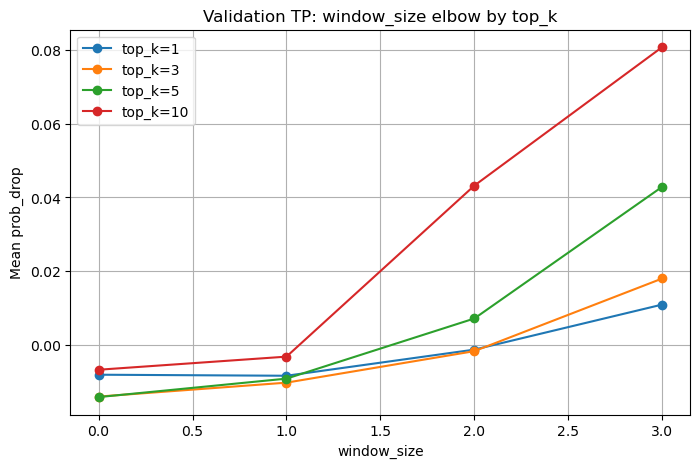

In [43]:
plt.figure(figsize=(8, 5))

for top_k in sorted(val_config_summary["top_k"].unique()):
    subset = val_config_summary[
        val_config_summary["top_k"] == top_k
    ].sort_values("window_size")
    
    plt.plot(
        subset["window_size"],
        subset["mean_prob_drop"],
        marker="o",
        label=f"top_k={top_k}"
    )

plt.xlabel("window_size")
plt.ylabel("Mean prob_drop")
plt.title("Validation TP: window_size elbow by top_k")
plt.grid(True)
plt.legend()
plt.show()

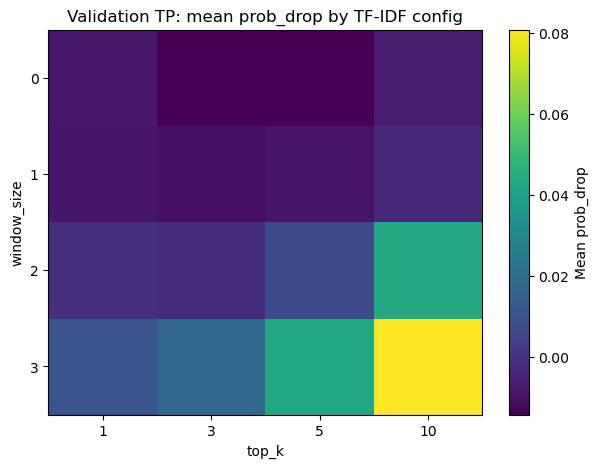

top_k,1,3,5,10
window_size,,,,
0,-0.008098,-0.014030,-0.014165,-0.006748
1,-0.008379,-0.010250,-0.009160,-0.003194
2,-0.001291,-0.001704,0.007151,0.043198
3,0.010931,0.018001,0.042885,0.080769


In [44]:
heatmap_data = val_config_summary.pivot(
    index="window_size",
    columns="top_k",
    values="mean_prob_drop"
)

plt.figure(figsize=(7, 5))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Mean prob_drop")
plt.xticks(
    ticks=np.arange(len(heatmap_data.columns)),
    labels=heatmap_data.columns
)
plt.yticks(
    ticks=np.arange(len(heatmap_data.index)),
    labels=heatmap_data.index
)
plt.xlabel("top_k")
plt.ylabel("window_size")
plt.title("Validation TP: mean prob_drop by TF-IDF config")
plot_path = val_output_dir / "tfidf_val_find_config_heatmap.png"
plt.savefig(plot_path, dpi=300)
plt.show()

display(heatmap_data)

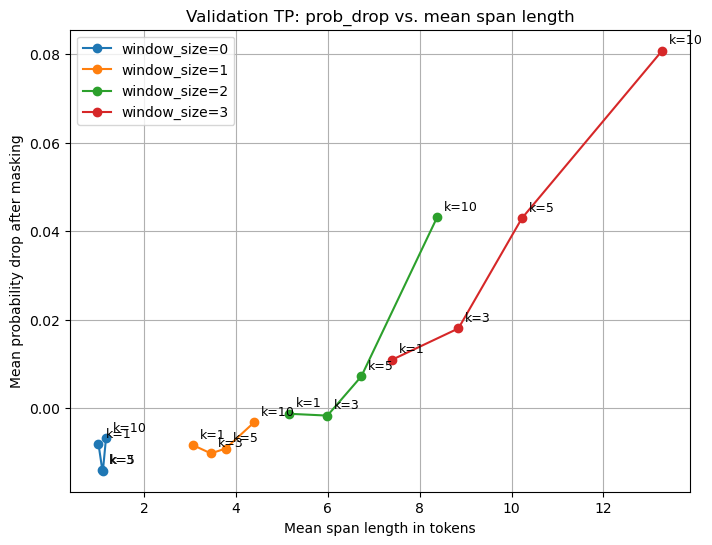

In [45]:
plt.figure(figsize=(8, 6))

for window_size in sorted(val_config_summary["window_size"].unique()):
    subset = val_config_summary[
        val_config_summary["window_size"] == window_size
    ].sort_values("top_k")
    
    plt.plot(
        subset["mean_span_len_tokens"],
        subset["mean_prob_drop"],
        marker="o",
        label=f"window_size={window_size}"
    )
    
    for _, row in subset.iterrows():
        plt.annotate(
            f"k={int(row['top_k'])}",
            (row["mean_span_len_tokens"], row["mean_prob_drop"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

plt.xlabel("Mean span length in tokens")
plt.ylabel("Mean probability drop after masking")
plt.title("Validation TP: prob_drop vs. mean span length")
plt.grid(True)
plt.legend()
plot_path = val_output_dir / "tfidf_val_prob_drop_vs_mean_span_len.png"
plt.savefig(plot_path, dpi=300)
plt.show()

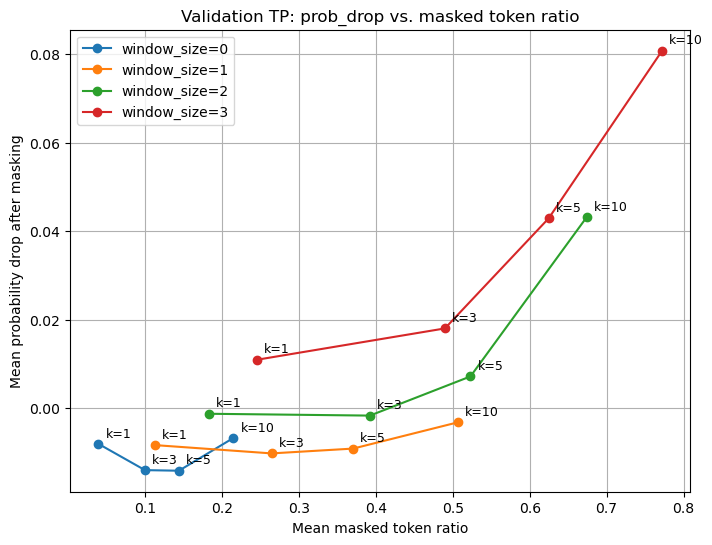

Saved plot: tfidf_baseline_results/validation_config_selection/tfidf_validation_prob_drop_vs_masked_token_ratio.png


In [46]:
plt.figure(figsize=(8, 6))

for window_size in sorted(val_config_summary["window_size"].unique()):
    subset = val_config_summary[
        val_config_summary["window_size"] == window_size
    ].sort_values("top_k")
    
    plt.plot(
        subset["mean_masked_token_ratio"],
        subset["mean_prob_drop"],
        marker="o",
        label=f"window_size={window_size}"
    )
    
    for _, row in subset.iterrows():
        plt.annotate(
            f"k={int(row['top_k'])}",
            (row["mean_masked_token_ratio"], row["mean_prob_drop"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

plt.xlabel("Mean masked token ratio")
plt.ylabel("Mean probability drop after masking")
plt.title("Validation TP: prob_drop vs. masked token ratio")
plt.grid(True)
plt.legend()

plot_path = val_output_dir / "tfidf_validation_prob_drop_vs_masked_token_ratio.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

In [47]:
BEST_WINDOW_SIZE = 3
BEST_TOP_K = 1

selected_config_summary = val_config_summary[
    (val_config_summary["window_size"] == BEST_WINDOW_SIZE) &
    (val_config_summary["top_k"] == BEST_TOP_K)
]

display(selected_config_summary)

,window_size,top_k,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,...,median_masked_token_ratio,mean_word_tfidf_nonzero_ratio,mean_vector_nonzero_ratio,n_spans,mean_span_len_tokens,median_span_len_tokens,mean_span_len_chars,median_span_len_chars,prob_drop_per_masked_token,prob_drop_per_masked_ratio
12,3,1,88,0.010931,-0.000042,0.143443,0.981915,0.970984,1.931818,14.295455,...,0.202356,0.362107,0.005139,170,7.4,7.0,40.905882,38.0,0.000765,0.044493


## Selected TF-IDF baseline configuration

The TF-IDF baseline was tuned on validation true positives, i.e., arguments that were labeled as inappropriate and also predicted as inappropriate by the document-level classifier. This keeps the configuration selection comparable to the other span localization methods.

The evaluated configurations varied `top_k ∈ {1, 3, 5, 10}` and `window_size ∈ {0, 1, 2, 3}`. The highest probability drops were obtained by larger configurations, but these also masked a large share of the argument. Since the goal is span localization rather than masking most of the document, the final configuration was selected based on the trade-off between probability drop and masked token ratio.

Final selected configuration:

- `window_size = 3`
- `top_k = 1`

This setting produced a positive probability drop while keeping the average masked-token ratio substantially lower than larger configurations such as `top_k=5` or `top_k=10`.

In [48]:
trainval_df = pd.concat([train_df, val_df], ignore_index=True)

tfidf_vectorizer_final = TfidfVectorizer(
    lowercase=True,
    stop_words=TFIDF_STOP_WORDS,
    ngram_range=TFIDF_NGRAM_RANGE,
    min_df=TFIDF_MIN_DF,
    max_df=TFIDF_MAX_DF,
    norm=TFIDF_NORM,
    sublinear_tf=TFIDF_SUBLINEAR_TF
)

X_trainval_tfidf = tfidf_vectorizer_final.fit_transform(trainval_df["text_norm"])
X_test_tfidf = tfidf_vectorizer_final.transform(test_df["text_norm"])

feature_names_final = np.array(tfidf_vectorizer_final.get_feature_names_out())

print("Train+validation TF-IDF:", X_trainval_tfidf.shape)
print("Test TF-IDF:", X_test_tfidf.shape)
print("Vocabulary size:", len(feature_names_final))

Train+validation TF-IDF: (1753, 5153)
Test TF-IDF: (438, 5153)
Vocabulary size: 5153


In [49]:
test_positions = list(range(len(test_df)))

test_results = run_tfidf_config_on_indices(
    df=test_df,
    X_tfidf=X_test_tfidf,
    feature_names=feature_names_final,
    matrix_positions=test_positions,
    top_k_values=[BEST_TOP_K],
    window_size_values=[BEST_WINDOW_SIZE],
    mask_token=MASK_TOKEN
)

test_argument_df = build_argument_level_df(test_results)
test_span_df = build_span_level_df(test_results)

display(test_argument_df.head())
display(test_span_df.head())

Building TF-IDF spans:   0%|          | 0/438 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/28 [00:00<?, ?it/s]

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,masked_token_ratio,merged_span_texts,merged_span_token_start_indices,merged_span_token_end_indices,merged_span_char_start_indices,merged_span_char_end_indices,top_terms_json,merged_spans_json,text,masked_text
0,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,0.892726,FN,False,True,...,0.500000,[students should wear what they like],[0],[5],[0],[35],"[{""term"": ""wear"", ""tfidf"": 0.48502589832216064}]","[{""char_start"": 0, ""char_end"": 35, ""token_star...",students should wear what they like and feel f...,[MASK] and feel free about their clothes
1,1754,test,8,Tv is better than books:,1,LABEL_1,0.997475,TP,True,False,...,0.160000,[and it is educational],[21],[24],[91],[112],"[{""term"": ""educational"", ""tfidf"": 0.6171888150...","[{""char_start"": 91, ""char_end"": 112, ""token_st...",I thick that book are better than TV is it is ...,I thick that book are better than TV is it is ...
2,1755,test,9,Tv is better than books:,1,LABEL_1,0.998255,TP,True,False,...,0.200000,[Books enlighten the soul. Books don't destroy...,"[0, 9]","[7, 15]","[0, 50]","[45, 90]","[{""term"": ""books"", ""tfidf"": 0.3575985492220799}]","[{""char_start"": 0, ""char_end"": 45, ""token_star...",Books enlighten the soul. Books don't destroy ...,"[MASK] the [MASK] into a series of questions, ..."
3,1756,test,12,India has the potential to lead the world:,1,LABEL_1,0.995627,TP,True,False,...,0.437500,[bad developer and leader should be a],[7],[13],[31],[67],"[{""term"": ""leader"", ""tfidf"": 0.660650172865158}]","[{""char_start"": 31, ""char_end"": 67, ""token_sta...",india is is good adopter but a bad developer a...,india is is good adopter but a [MASK] great de...
4,1757,test,15,Is it better to have a lousy father or to be f...,0,LABEL_0,0.993661,TN,False,False,...,0.160714,"[rather be completely fatherless, not saying t...","[3, 28, 108]","[9, 34, 111]","[14, 156, 581]","[62, 201, 609]","[{""term"": ""fatherless"", ""tfidf"": 0.28430532286...","[{""char_start"": 14, ""char_end"": 62, ""token_sta...","Honestly, I'd rather be completely fatherless,...","Honestly, I'd [MASK] not having is better than..."


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,anchor_tfidf_values,span_score_sum_tfidf,p_inappropriate_original,p_inappropriate_masked,prob_drop,n_word_tokens,word_tfidf_nonzero_ratio,vector_nonzero_ratio,text,masked_text
0,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,FN,False,True,False,...,[0.48502589832216064],0.485026,0.107274,0.357836,-0.250563,12,0.500000,0.001164,students should wear what they like and feel f...,[MASK] and feel free about their clothes
1,1754,test,8,Tv is better than books:,1,LABEL_1,TP,True,False,False,...,[0.6171888150448267],0.617189,0.997475,0.997851,-0.000376,25,0.200000,0.000776,I thick that book are better than TV is it is ...,I thick that book are better than TV is it is ...
2,1755,test,9,Tv is better than books:,1,LABEL_1,TP,True,False,False,...,"[0.3575985492220799, 0.3575985492220799]",0.715197,0.998255,0.968914,0.029341,75,0.346667,0.004657,Books enlighten the soul. Books don't destroy ...,"[MASK] the [MASK] into a series of questions, ..."
3,1755,test,9,Tv is better than books:,1,LABEL_1,TP,True,False,False,...,[0.3575985492220799],0.357599,0.998255,0.968914,0.029341,75,0.346667,0.004657,Books enlighten the soul. Books don't destroy ...,"[MASK] the [MASK] into a series of questions, ..."
4,1756,test,12,India has the potential to lead the world:,1,LABEL_1,TP,True,False,False,...,[0.660650172865158],0.660650,0.995627,0.972570,0.023057,16,0.312500,0.000970,india is is good adopter but a bad developer a...,india is is good adopter but a [MASK] great de...


In [50]:
test_overall_summary = (
    test_argument_df
    .groupby(["window_size", "top_k"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        mean_word_tfidf_nonzero_ratio=("word_tfidf_nonzero_ratio", "mean"),
        mean_vector_nonzero_ratio=("vector_nonzero_ratio", "mean"),
    )
    .reset_index()
)

test_confusion_summary = (
    test_argument_df
    .groupby("confusion_type")
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        mean_word_tfidf_nonzero_ratio=("word_tfidf_nonzero_ratio", "mean"),
        mean_vector_nonzero_ratio=("vector_nonzero_ratio", "mean"),
    )
    .reset_index()
    .sort_values("confusion_type")
)

display(test_overall_summary)
display(test_confusion_summary)

,window_size,top_k,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio,mean_word_tfidf_nonzero_ratio,mean_vector_nonzero_ratio
0,3,1,438,-0.099545,-0.000161,0.312248,0.590804,0.690349,2.136986,15.573059,0.233869,0.356513,0.004699


,confusion_type,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio,mean_word_tfidf_nonzero_ratio,mean_vector_nonzero_ratio
0,FN,39,-0.347890,-0.058616,0.415721,0.049638,0.397528,2.205128,16.589744,0.221810,0.360742,0.005299
1,FP,71,0.034198,-0.000074,0.204195,0.971585,0.937388,1.873239,14.028169,0.246185,0.362544,0.004362
2,TN,142,-0.241840,-0.004346,0.387237,0.037216,0.279056,2.485915,17.725352,0.208715,0.347474,0.005195
3,TP,186,0.010109,-0.000017,0.131327,0.981555,0.971446,1.956989,14.306452,0.250900,0.360226,0.004324


In [51]:
def make_json_serializable(obj):
    """Convert numpy and pandas scalar types to JSON-serializable Python types."""
    if isinstance(obj, dict):
        return {str(k): make_json_serializable(v) for k, v in obj.items()}
    
    if isinstance(obj, list):
        return [make_json_serializable(v) for v in obj]
    
    if isinstance(obj, tuple):
        return [make_json_serializable(v) for v in obj]
    
    if isinstance(obj, np.integer):
        return int(obj)
    
    if isinstance(obj, np.floating):
        return float(obj)
    
    if isinstance(obj, np.bool_):
        return bool(obj)
    
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    
    if obj is pd.NA:
        return None
    
    try:
        if pd.isna(obj):
            return None
    except Exception:
        pass
    
    return obj

In [52]:
test_output_dir = OUTPUT_DIR / f"final_test_all_window{BEST_WINDOW_SIZE}_topk{BEST_TOP_K}"
test_output_dir.mkdir(parents=True, exist_ok=True)

argument_csv_path = test_output_dir / f"tfidf_final_test_all_window{BEST_WINDOW_SIZE}_topk{BEST_TOP_K}_argument_level.csv"
span_csv_path = test_output_dir / f"tfidf_final_test_all_window{BEST_WINDOW_SIZE}_topk{BEST_TOP_K}_span_level.csv"
overall_summary_csv_path = test_output_dir / f"tfidf_final_test_all_window{BEST_WINDOW_SIZE}_topk{BEST_TOP_K}_overall_summary.csv"
confusion_summary_csv_path = test_output_dir / f"tfidf_final_test_all_window{BEST_WINDOW_SIZE}_topk{BEST_TOP_K}_confusion_summary.csv"
jsonl_path = test_output_dir / f"tfidf_final_test_all_window{BEST_WINDOW_SIZE}_topk{BEST_TOP_K}_argument_level.jsonl"

test_argument_df.to_csv(argument_csv_path, index=False, encoding="utf-8")
test_span_df.to_csv(span_csv_path, index=False, encoding="utf-8")
test_overall_summary.to_csv(overall_summary_csv_path, index=False, encoding="utf-8")
test_confusion_summary.to_csv(confusion_summary_csv_path, index=False, encoding="utf-8")

with open(jsonl_path, "w", encoding="utf-8") as f:
    for result in test_results:
        safe_result = make_json_serializable(result)
        f.write(json.dumps(safe_result, ensure_ascii=False) + "\n")

print("Saved:")
print(argument_csv_path)
print(span_csv_path)
print(overall_summary_csv_path)
print(confusion_summary_csv_path)
print(jsonl_path)

Saved:
tfidf_baseline_results/final_test_all_window3_topk1/tfidf_final_test_all_window3_topk1_argument_level.csv
tfidf_baseline_results/final_test_all_window3_topk1/tfidf_final_test_all_window3_topk1_span_level.csv
tfidf_baseline_results/final_test_all_window3_topk1/tfidf_final_test_all_window3_topk1_overall_summary.csv
tfidf_baseline_results/final_test_all_window3_topk1/tfidf_final_test_all_window3_topk1_confusion_summary.csv
tfidf_baseline_results/final_test_all_window3_topk1/tfidf_final_test_all_window3_topk1_argument_level.jsonl


In [56]:
from IPython.display import HTML, display
import html


def highlight_spans(text, spans):
    """Highlight multiple character spans in one text."""
    text = str(text)
    
    if not spans:
        return html.escape(text)
    
    spans = sorted(spans, key=lambda x: x["char_start"])
    
    parts = []
    last_end = 0
    
    for span in spans:
        start = int(span["char_start"])
        end = int(span["char_end"])
        
        if start < last_end:
            continue
        
        parts.append(html.escape(text[last_end:start]))
        parts.append(
            "<mark style='background-color:#ffe58a; padding:2px 4px; border-radius:4px;'>"
            + html.escape(text[start:end])
            + "</mark>"
        )
        last_end = end
    
    parts.append(html.escape(text[last_end:]))
    
    return "".join(parts)


def show_attention_example(result_df, index=0):
    """Display one TF-IDF result with highlighted masked spans."""
    row = result_df.iloc[index]
    
    spans = json.loads(row["merged_spans_json"])
    marked = highlight_spans(row["text"], spans)
    
    display(HTML(f"""
    <div style="
        border:1px solid #ccc;
        border-radius:8px;
        padding:14px;
        margin:12px 0;
        font-family:Arial, sans-serif;
        line-height:1.45;
    ">
        <b>global_row_id:</b> {html.escape(str(row["global_row_id"]))}<br>
        <b>post_id:</b> {html.escape(str(row["post_id"]))}<br>
        <b>split:</b> {html.escape(str(row["split"]))}<br>
        <b>confusion_type:</b> {html.escape(str(row["confusion_type"]))}<br>
        <b>issue:</b> {html.escape(str(row["issue"]))}<br>
        <b>top_k:</b> {row["top_k"]} |
        <b>window_size:</b> {row["window_size"]}<br>
        <b>merged_spans:</b> {html.escape(str(row["merged_span_texts"]))}<br>
        <b>p_original:</b> {float(row["p_inappropriate_original"]):.4f}<br>
        <b>p_masked:</b> {float(row["p_inappropriate_masked"]):.4f}<br>
        <b>prob_drop:</b> {float(row["prob_drop"]):.4f}<br>
        <b>masked_token_ratio:</b> {float(row["masked_token_ratio"]):.4f}<br>
        <hr>
        <p>{marked}</p>
    </div>
    """))

In [57]:
# Best test examples by probability drop
tmp = (
    test_argument_df
    .sort_values("prob_drop", ascending=False)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp))):
    show_attention_example(tmp, index=i)